In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid")

In [4]:
#loading the dataset
cancer_data=load_breast_cancer()

df=pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df["target"]=cancer_data.target

print(f"Dataset shape: {df.shape}")
print(f"Class distribution: {cancer_data.target_names[0]}={sum(df["target"]==0)}, {cancer_data.target_names[1]}={sum(df["target"]==1)}"
)

df.head()

Dataset shape: (569, 31)
Class distribution: malignant=212, benign=357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
X=cancer_data.data
y=cancer_data.target

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print("Data is successfully split and scaled.")

Data is successfully split and scaled.


In [7]:
model=LogisticRegression(random_state=42, max_iter=10000)
model.fit(X_train_scaled, y_train)

y_pred=model.predict(X_test_scaled)
y_prob=model.predict_proba(X_test_scaled)[:, 1]

print("Model training complete.")

Model training complete.


In [8]:
accuracy=accuracy_score(y_test, y_pred)
roc_auc=roc_auc_score(y_test, y_prob)


print(f"Model Accuracy Score: {accuracy:.4f}")
print(f"ROC AUC Score:        {roc_auc:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer_data.target_names))

Model Accuracy Score: 0.9825
ROC AUC Score:        0.9954
Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



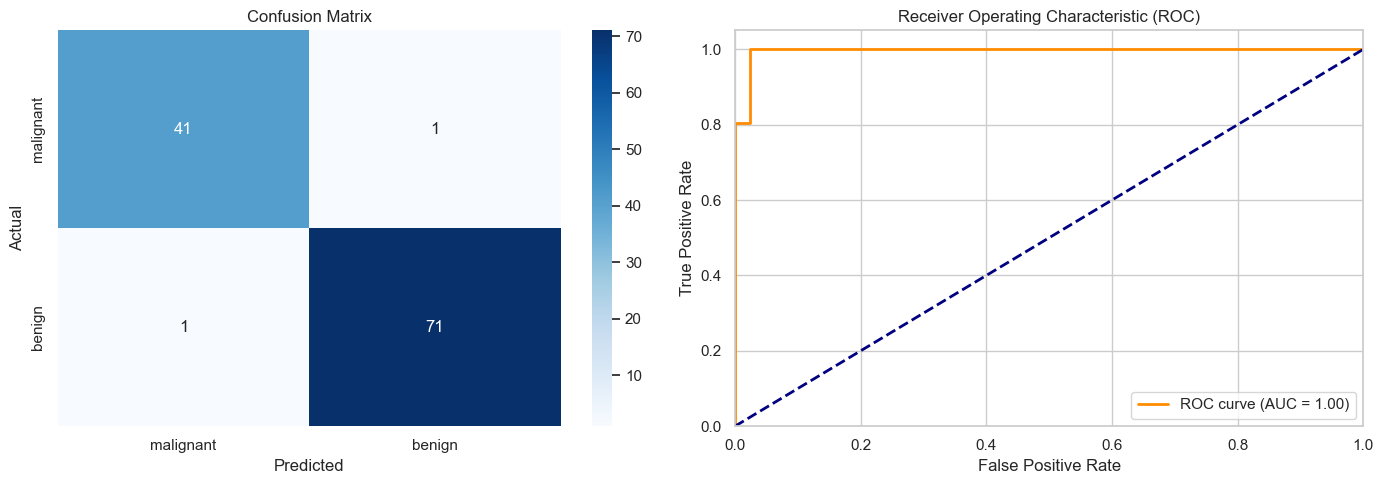

In [9]:
fig, axes=plt.subplots(1, 2, figsize=(14, 5))

#Confusion Matrix
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cancer_data.target_names,
    yticklabels=cancer_data.target_names,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

#Plotting ROC Curve
fpr, tpr, _=roc_curve(y_test, y_prob)
axes[1].plot(
    fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"

)

axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Receiver Operating Characteristic (ROC)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [14]:
feature_importance=pd.DataFrame(
    {"Feature": cancer_data.feature_names, "Coefficient": model.coef_[0]}
)
feature_importance["Absolute_Impact"]=feature_importance["Coefficient"].abs()
feature_importance=feature_importance.sort_values(
    by="Absolute_Impact", ascending=False
)
print("Top 10 Most Influential Features:")
feature_importance.head(10)[["Feature", "Coefficient"]]

Top 10 Most Influential Features:


,Feature,Coefficient
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625
